# Integrative Analysis of Breast Cancer Susceptibility Loci and Tumor Immune Programs Reveals Immune-Associated Candidate Genes in Triple-Negative Breast Cancer

---
## Notebook 2 - Identification and Annotation of Breast Cancer Susceptibility Genes


### Objective

This notebook maps genome-wide significant breast cancer susceptibility variants to nearby protein-coding genes using genomic coordinates obtained from Ensembl BioMart. The resulting candidate gene set provides the functional bridge between inherited genetic variation and downstream transcriptomic and pathway analyses.

### Biological Background

Genome-wide association studies identify disease-associated variants rather than the genes they regulate. Because many susceptibility variants occur within non-coding regions of the genome, their biological interpretation requires an additional mapping step.

A common strategy is positional mapping, where significant variants are assigned to nearby genes within a defined genomic window. Although this approach does not establish causality, it provides a biologically plausible set of candidate susceptibility genes for downstream functional analyses.

In this study, genome-wide significant SNPs were mapped to nearby protein-coding genes using genomic coordinates from Ensembl BioMart.

In [1]:
import requests
from io import StringIO
import urllib3

import pandas as pd
import numpy as np

import scipy.stats as stats

import matplotlib.pyplot as plt
import seaborn as sns

### 1. Load genome-wide significant SNPs identified in Notebook 1

In [2]:
snps_df = pd.read_csv("../data/gwas/gwas_significant_hits.tsv", sep='\t')
print(f"Loaded {len(snps_df)} significant SNPs for gene mapping.")

Loaded 2085 significant SNPs for gene mapping.


### 2. Retrieve genomic coordinates for human protein-coding genes from Ensembl BioMart.

In [3]:
urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

print("Fetching human gene coordinates from Ensembl BioMart mirror...")

url = "https://www.ensembl.org/biomart/martservice"

query = """<?xml version="1.0" encoding="UTF-8"?>
<!DOCTYPE Document>
<Document format="TSV" header="1" uniqueRows="1" count="" datasetConfigVersion="0.6">
    <Dataset name="hsapiens_gene_ensembl" interface="default">
        <Attribute name="chromosome_name" />
        <Attribute name="start_position" />
        <Attribute name="end_position" />
        <Attribute name="external_gene_name" />
        <Attribute name="gene_biotype" />
    </Dataset>
</Document>"""

response = requests.get(url, params={'query': query}, verify=False)

if response.status_code == 200:
    genes_df = pd.read_csv(StringIO(response.text), sep='\t')
    genes_df.columns = [col.strip() for col in genes_df.columns]
    genes_df.columns = ['chromosome', 'gene_start', 'gene_end', 'gene_name', 'biotype']
    
    genes_df = genes_df[genes_df['biotype'] == 'protein_coding']
    genes_df = genes_df[genes_df['chromosome'].astype(str).isin([str(i) for i in range(1, 23)])]
    genes_df['chromosome'] = genes_df['chromosome'].astype(int)
    
    print(f"Loaded reference map for {len(genes_df)} human protein-coding genes.")
    print(genes_df.head())
else:
    print(f"Failed to fetch data from BioMart. Status code: {response.status_code}")

Fetching human gene coordinates from Ensembl BioMart mirror...
Loaded reference map for 19165 human protein-coding genes.
      chromosome  gene_start  gene_end gene_name         biotype
2103          13    23979700  24321031       NaN  protein_coding
2137          13    45534522  45615739   ERICH6B  protein_coding
2181          13    57147488  57150509    PRR20B  protein_coding
2201          13    57160632  57163653    PRR20D  protein_coding
2205          13    57167197  57170218    PRR20E  protein_coding


#### Biological Interpretation

The reference annotation contains protein-coding genes distributed across the autosomal chromosomes. Restricting the analysis to protein-coding genes focuses subsequent analyses on genes with established coding potential while reducing ambiguity introduced by non-coding loci.

### 3. Map significant SNPs to nearby genes using a ±250 kb genomic window.

In [4]:
mapped_results = []
window_size = 250000 

print("Mapping SNPs to genes based on genomic windows...")

snps_arr = snps_df[['rsid', 'chromosome', 'position', 'p_value']].values
genes_arr = genes_df[['chromosome', 'gene_start', 'gene_end', 'gene_name']].values

for snp in snps_arr:
    s_id, s_chrom, s_pos, s_p = snp
    
    same_chrom_genes = genes_arr[genes_arr[:, 0] == s_chrom]
    
    for gene in same_chrom_genes:
        _, g_start, g_end, g_name = gene
        
        if (s_pos >= (g_start - window_size)) and (s_pos <= (g_end + window_size)):
            mapped_results.append({
                'rsid': s_id,
                'chromosome': s_chrom,
                'snp_position': s_pos,
                'p_value': s_p,
                'gene_name': g_name
            })

mapping_output = pd.DataFrame(mapped_results)
print(f"Mapping complete! Found {len(mapping_output)} total SNP-to-Gene pairings.")

Mapping SNPs to genes based on genomic windows...
Mapping complete! Found 13808 total SNP-to-Gene pairings.


#### Biological Interpretation

Multiple SNPs frequently map to the same gene because association signals often occur within regions of linkage disequilibrium. Consequently, the analysis produces SNP-to-gene relationships rather than a one-to-one correspondence between variants and genes.

### 4. Collapse multiple SNP-to-gene mappings into a non-redundant candidate gene list.

In [5]:
unique_genes = mapping_output.groupby('gene_name').agg({
    'rsid': 'count',                
    'p_value': 'min'                  
}).rename(columns={'rsid': 'snp_count', 'p_value': 'best_p_value'}).reset_index()


unique_genes = unique_genes.sort_values('best_p_value')

print(f"GWAS signals have successfully mapped to {len(unique_genes)} unique genes!")
print("\nTop 10 most genetically associated candidate genes:")
print(unique_genes.head(10))

Your GWAS signals have successfully mapped to 193 unique genes!

Top 10 most genetically associated candidate genes:
    gene_name  snp_count  best_p_value
0       ABHD8        241  9.658000e-64
5      ANKLE1        241  9.658000e-64
6        ANO8        241  9.658000e-64
14       BST2        241  9.658000e-64
12     BABAM1        241  9.658000e-64
24    CCDC194        241  9.658000e-64
46       DDA1        241  9.658000e-64
105     OCEL1        241  9.658000e-64
97     NIBAN3        180  9.658000e-64
103     NXNL1        238  9.658000e-64


### 5. Distribution of Significant SNPs Bar Plot

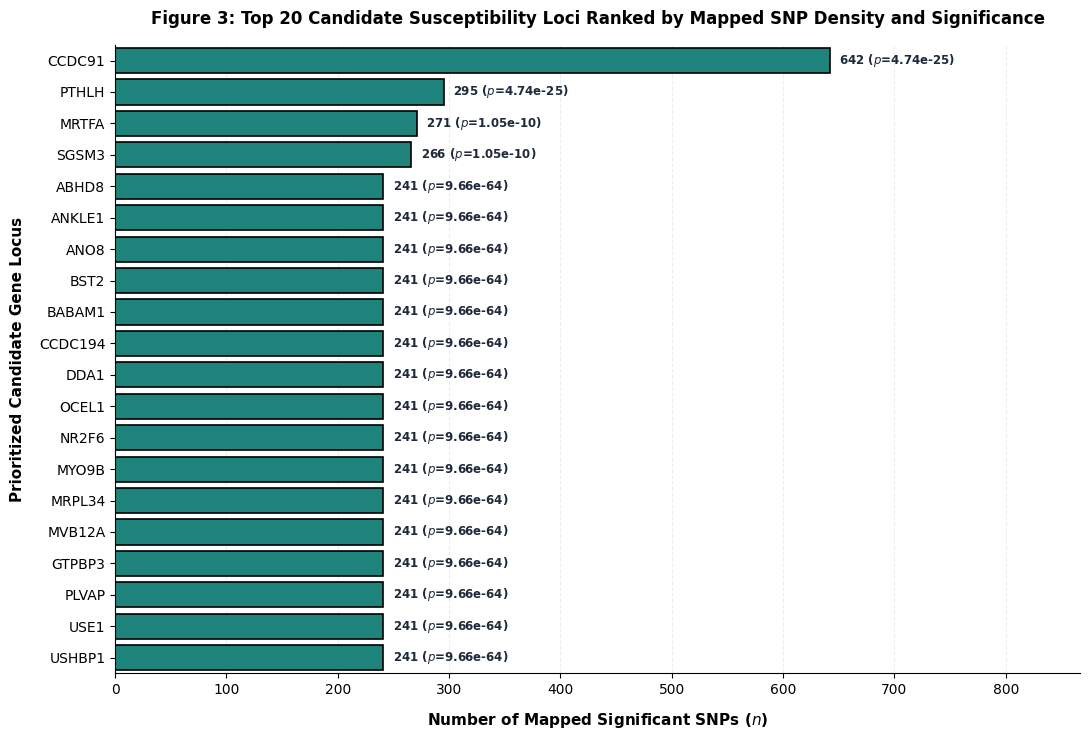

In [6]:
top_20_snp_density = unique_genes.sort_values(by=['snp_count', 'best_p_value'], ascending=[False, True]).head(20)

fig, ax = plt.subplots(figsize=(11, 7.5))

bar = sns.barplot(
    data=top_20_snp_density,
    x='snp_count',
    y='gene_name',
    color='#0D9488',  
    edgecolor='black',
    linewidth=1.2,
    ax=ax
)

ax.set_title('Figure 3: Top 20 Candidate Susceptibility Loci Ranked by Mapped SNP Density and Significance', fontsize=12, fontweight='bold', pad=15)
ax.set_xlabel('Number of Mapped Significant SNPs ($n$)', fontsize=11, fontweight='bold', labelpad=10)
ax.set_ylabel('Prioritized Candidate Gene Locus', fontsize=11, fontweight='bold', labelpad=10)

for patch, (_, row) in zip(ax.patches, top_20_snp_density.iterrows()):
    width = patch.get_width()
    p_val_scientific = f"{row['best_p_value']:.2e}"
    
    annotation_text = f" {int(width)} ($p$={p_val_scientific})"
    
    ax.text(
        width + 5, 
        patch.get_y() + patch.get_height() / 2, 
        annotation_text, 
        ha='left', 
        va='center', 
        fontsize=8.5, 
        fontweight='bold',
        color='#1E293B'
    )
    
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.xaxis.grid(True, linestyle='--', alpha=0.4, color='#CBD5E1')
ax.set_axisbelow(True)

ax.set_xlim(0, max(top_20_snp_density['snp_count']) * 1.35)

plt.tight_layout()
plt.savefig('../results/figures/gwas_gene_snp_distribution_with_pvalue.png', dpi=300, bbox_inches='tight')

#### Biological Interpretation

A total of **193 unique protein-coding genes** were identified near genome-wide significant susceptibility loci.

These genes represent candidate mediators of inherited breast cancer risk and serve as the primary biological entities for all downstream analyses, including functional enrichment, transcriptomic integration, immune characterization, and network analysis.

### 6. Export the susceptibility gene set for functional enrichment and transcriptomic integration.

In [7]:
unique_genes.to_csv("../data/gwas/gwas_mapped_unique_genes.csv", index=False)

### Notebook Summary

Genome-wide significant susceptibility loci were successfully translated into a biologically interpretable set of candidate genes through positional mapping.

This mapping step transforms statistical association signals into functional genomic entities that can be integrated with transcriptomic data and investigated for their potential roles in tumor biology.

#### Biological overview
GWAS identifies where inherited disease-associated variants occur within the genome, but genes—not SNPs—are the functional units that drive biological processes.

By mapping significant variants to nearby protein-coding genes, we establish the link between inherited genetic susceptibility and the molecular pathways that will be explored throughout the remainder of this study.